# Task 2
This serves as a template which will guide you through the implementation of this task. It is advised to first read the whole template and get a sense of the overall structure of the code before trying to fill in any of the TODO gaps.
This is the jupyter notebook version of the template. For the python file version, please refer to the file `template_solution.py`.

First, we import necessary libraries:

In [21]:
import numpy as np
import pandas as pd
# Add any other imports you need here

# for categorical feature oneHotEncoding
from sklearn import preprocessing

# for missing data imputers
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# to make a pipeline (combine scaler and regressor in one line) and to use the Scaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# for the Gaussian regressors
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, RBF, Matern, RationalQuadratic
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel

# for cross-validation
from sklearn.model_selection import KFold

# for the R2 metric
from sklearn.metrics import r2_score

# for plotting
import matplotlib.pyplot as plt


# Data Loading
TODO: Perform data preprocessing, imputation and extract X_test, y_train and X_test
(and potentially change initialization of variables to accomodate how you deal with non-numeric data)

In [2]:
"""
This loads the training and test data, preprocesses it, removes the NaN
values and interpolates the missing data using imputation

Parameters
----------
Compute
----------
X_train: matrix of floats, training input with features
y_train: array of floats, training output with labels
X_test: matrix of floats: dim = (100, ?), test input with features
"""
# Load training data
train_df = pd.read_csv("../train.csv")
    
print("Training data:")
print("Shape:", train_df.shape)
print(train_df.head(2))
print('\n')
    
# Load test data
test_df = pd.read_csv("../test.csv")

print("Test data:")
print(test_df.shape)
print(test_df.head(2))


Training data:
Shape: (900, 11)
   season  price_AUS  price_CHF  price_CZE  price_GER  price_ESP  price_FRA  \
0  spring  -3.348808        NaN  -3.597534  -4.102160  -2.201652  -2.806995   
1  summer  -3.421345  -1.455502  -3.597649  -3.675204        NaN  -2.440406   

   price_UK  price_ITA  price_POL  price_SVK  
0       NaN   -3.61728  -2.758448        NaN  
1 -2.379524        NaN        NaN   -3.72506  


Test data:
(100, 10)
   season  price_AUS  price_CZE  price_GER  price_ESP  price_FRA  price_UK  \
0  spring  -1.504285  -1.632302  -2.347618        NaN        NaN -3.437325   
1  summer  -1.779837  -1.750216  -2.407555  -1.875685        NaN       NaN   

   price_ITA  price_POL  price_SVK  
0  -3.505886  -2.042408        NaN  
1  -3.528359  -2.131659  -2.911154  


In [3]:
train_df.describe()

,price_AUS,price_CHF,price_CZE,price_GER,price_ESP,price_FRA,price_UK,price_ITA,price_POL,price_SVK
count,632.000000,638.000000,600.000000,654.000000,648.000000,631.000000,632.000000,608.000000,631.000000,626.000000
mean,-1.115052,0.920575,-1.199427,-1.150482,-2.857563,-2.004003,-1.703043,-2.490844,-0.711264,-1.199012
std,1.694526,2.844494,1.929272,2.082610,1.147736,1.575536,1.682675,1.349527,2.041835,2.150985
min,-3.695923,-6.004525,-3.943053,-4.354692,-4.741744,-3.802034,-3.674433,-3.953279,-3.059780,-4.014550
25%,-2.835545,-1.502571,-3.188078,-3.212811,-3.693699,-3.104778,-3.109142,-3.542207,-2.542737,-3.248707
50%,-1.116466,1.275067,-1.180107,-1.019859,-2.896516,-2.419280,-2.230205,-3.083380,-1.315759,-1.567850
75%,0.407087,2.843812,0.240229,0.764429,-2.029695,-1.718939,-0.871423,-1.544665,0.913809,0.733426
max,2.561372,7.630330,2.692054,2.870038,0.859972,1.868519,2.264310,1.762168,4.561962,3.629820


In [4]:
test_df.describe()

,price_AUS,price_CZE,price_GER,price_ESP,price_FRA,price_UK,price_ITA,price_POL,price_SVK
count,68.000000,69.000000,65.000000,72.000000,78.000000,72.000000,65.000000,68.000000,73.000000
mean,-2.082027,-2.399782,-2.013502,-2.540415,-1.574993,-1.301242,-2.846194,-1.577895,-2.316462
std,1.873412,1.913226,2.240663,0.831840,1.631530,1.608500,1.431698,2.204088,2.268664
min,-3.661058,-3.888736,-4.199959,-3.545370,-3.708390,-3.712619,-3.869728,-3.074721,-3.879689
25%,-3.378215,-3.580230,-3.457475,-3.082836,-2.413545,-2.153939,-3.564598,-2.793865,-3.538977
50%,-3.000655,-3.422321,-3.173840,-2.890606,-1.937162,-1.419676,-3.418043,-2.670872,-3.373481
75%,-1.650936,-2.002482,-0.897203,-1.908469,-1.275716,-0.690845,-3.218608,-2.037492,-2.873045
max,2.557148,2.547611,2.721481,0.575509,1.907177,2.229387,2.112763,4.284246,3.578411


Next we will impute the missing data and treat the categorical variables in different ways and store the different X_train, y_train, X_test differently. 

In [5]:
# first understand how much missing data there is
print("Null in train_df per column:")
print(np.sum(pd.isnull(train_df)))

print("Null in test_df per column:")
print(np.sum(pd.isnull(test_df)))

# around 30% in in each column in both the train_df and test_df. Season does not have any missing data.


Null in train_df per column:
season         0
price_AUS    268
price_CHF    262
price_CZE    300
price_GER    246
price_ESP    252
price_FRA    269
price_UK     268
price_ITA    292
price_POL    269
price_SVK    274
dtype: int64
Null in test_df per column:
season        0
price_AUS    32
price_CZE    31
price_GER    35
price_ESP    28
price_FRA    22
price_UK     28
price_ITA    35
price_POL    32
price_SVK    27
dtype: int64


c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [6]:
# dropping the rows or columns (only season remaining) is therefore not an option, the datasets becomes empty either way
print("After dropping the rows with nulls the shape of train_df is:")
print(np.shape(train_df.dropna(axis=0)))

print("After dropping the columns with nulls the shape of train_df is:")
print(np.shape(train_df.dropna(axis=1)))

After dropping the rows with nulls the shape of train_df is:
(0, 11)
After dropping the columns with nulls the shape of train_df is:
(900, 1)


However, all rows where price_CHF is null are dropped (262), because otherwise the regressor would just try to learn the imputer.

In [7]:
train_df = train_df.dropna(subset=['price_CHF'])
print("New train_df shape (with 262 fewer rows):")
print(np.shape(train_df))

New train_df shape (with 262 fewer rows):
(638, 11)


In [8]:

# Dummy initialization of the X_train, X_test and y_train   
# TODO: Depending on how you deal with the non-numeric data, you may want to 
# modify/ignore the initialization of these variables   
X_train_base = train_df.drop(['price_CHF'],axis=1)
y_train_base = train_df['price_CHF']
X_test_base = test_df

# TODO: Perform data preprocessing, imputation and extract X_train, y_train and X_test


A total of 6 different options will be evaluated: 2 different ways to transform the categorical feature season, and 3 different imputers.<br>
Option 1) called "oneSim" uses one-hot encoding for the categorical feature (season) and the SimpleImputer from sklearn<br>
Option 2) called "cycSim" uses cyclical encoding for the categorical feature (season) and the SimpleImputer from sklearn<br>
Option 3) called "oneIte" uses one-hot encoding for the categorical feature (season) and the IterativeImputer from sklearn<br>
Option 4) called "cycIte" uses cyclical encoding for the categorical feature (season) and the IterativeImputer from sklearn<br>
Option 5) called "oneKNN" uses one-hot encoding for the categorical feature (season) and the KNNImputer from sklearn<br>
Option 6) called "cycKNN" uses cyclical encoding for the categorical feature (season) and the KNNImputer from sklearn<br>
<br>
Cyclical encoding was chosen instead of ordinal encoding because autumn and winter are adjacent but in ordinal encoding they would result furthest away, for example winter = 1 and autumn = 4 or winter = 0 and autumn = 3. Instead, cyclical encoding is able to keep correct distances by placing them on a unit circle, generating 2 features, one per axis of the unit circle, out of 1 (sine and cosine calculations not required).<br>
winter: season_x = 1, season_y = 0<br>
spring: season_x = 0, season_y = 1<br>
summer: season_x = -1, season_y = 0<br>
autumn: season_x = 0, season_y = -1

In [9]:
# the season OneHotEncoding

season_names = ['winter','spring','summer','autumn']

oneHotEnc = preprocessing.OneHotEncoder(
    categories=[season_names], 
    sparse_output=False
)

# for X_train
X_train_one_array = oneHotEnc.fit_transform(X_train_base[["season"]])
oneEncoded_df = pd.DataFrame(X_train_one_array, columns=season_names, index=X_train_base.index)
X_train_one = X_train_base.drop(columns=["season"])
X_train_one = pd.concat([oneEncoded_df, X_train_one], axis = 1)

# for X_test
X_test_one_array = oneHotEnc.fit_transform(X_test_base[["season"]])
oneEncoded_df = pd.DataFrame(X_test_one_array, columns=season_names, index=X_test_base.index)
X_test_one = X_test_base.drop(columns=["season"])
X_test_one = pd.concat([oneEncoded_df, X_test_one], axis = 1)

In [10]:
# the season cyclical encoding

X_train_cyc = X_train_base.copy()
X_train_cyc["season_x"] = 0
X_train_cyc["season_y"] = 0

X_train_cyc.loc[X_train_cyc["season"] == 'winter', 'season_x'] = 1
X_train_cyc.loc[X_train_cyc["season"] == 'winter', 'season_y'] = 0
X_train_cyc.loc[X_train_cyc["season"] == 'spring', 'season_x'] = 0
X_train_cyc.loc[X_train_cyc["season"] == 'spring', 'season_y'] = 1
X_train_cyc.loc[X_train_cyc["season"] == 'summer', 'season_x'] = -1
X_train_cyc.loc[X_train_cyc["season"] == 'summer', 'season_y'] = 0
X_train_cyc.loc[X_train_cyc["season"] == 'autumn', 'season_x'] = 0
X_train_cyc.loc[X_train_cyc["season"] == 'autumn', 'season_y'] = -1

X_train_cyc.drop(columns = "season", inplace = True)

X_test_cyc = X_test_base.copy()
X_test_cyc["season_x"] = 0
X_test_cyc["season_y"] = 0

X_test_cyc.loc[X_test_cyc["season"] == 'winter', 'season_x'] = 1
X_test_cyc.loc[X_test_cyc["season"] == 'winter', 'season_y'] = 0
X_test_cyc.loc[X_test_cyc["season"] == 'spring', 'season_x'] = 0
X_test_cyc.loc[X_test_cyc["season"] == 'spring', 'season_y'] = 1
X_test_cyc.loc[X_test_cyc["season"] == 'summer', 'season_x'] = -1
X_test_cyc.loc[X_test_cyc["season"] == 'summer', 'season_y'] = 0
X_test_cyc.loc[X_test_cyc["season"] == 'autumn', 'season_x'] = 0
X_test_cyc.loc[X_test_cyc["season"] == 'autumn', 'season_y'] = -1

X_test_cyc.drop(columns = "season", inplace = True)


In [ ]:
# simpleImputer

# X_train for oneHotEncoder
sim = SimpleImputer(missing_values = np.nan, strategy = 'mean')
X_train_oneSim_array = sim.fit_transform(X_train_one)
X_train_oneSim = pd.DataFrame(X_train_oneSim_array, columns=X_train_one.columns, index=X_train_one.index)

# X_test for oneHotEncoder
X_test_oneSim_array = sim.transform(X_test_one)
X_test_oneSim = pd.DataFrame(X_test_oneSim_array, columns=X_test_one.columns, index=X_test_one.index)

# X_train for cyclicEncoder
sim = SimpleImputer(missing_values = np.nan, strategy = 'mean')
X_train_cycSim_array = sim.fit_transform(X_train_cyc)
X_train_cycSim = pd.DataFrame(X_train_cycSim_array, columns=X_train_cyc.columns, index=X_train_cyc.index)

# X_test for cyclicEncoder
X_test_cycSim_array = sim.transform(X_test_cyc)
X_test_cycSim = pd.DataFrame(X_test_cycSim_array, columns=X_test_cyc.columns, index=X_test_cyc.index)



In [ ]:
# IterativeImputer

# X_train for oneHotEncoder
ite = IterativeImputer(max_iter=10, random_state=0)
X_train_oneIte_array = ite.fit_transform(X_train_one)
X_train_oneIte = pd.DataFrame(X_train_oneIte_array, columns=X_train_one.columns, index=X_train_one.index)

# X_test for oneHotEncoder
X_test_oneIte_array = ite.transform(X_test_one)
X_test_oneIte = pd.DataFrame(X_test_oneIte_array, columns=X_test_one.columns, index=X_test_one.index)

# X_train for cyclicEncoder
ite = IterativeImputer(max_iter=10, random_state=0)
X_train_cycIte_array = ite.fit_transform(X_train_cyc)
X_train_cycIte = pd.DataFrame(X_train_cycIte_array, columns=X_train_cyc.columns, index=X_train_cyc.index)

# X_test for cyclicEncoder
X_test_cycIte_array = ite.transform(X_test_cyc)
X_test_cycIte = pd.DataFrame(X_test_cycIte_array, columns=X_test_cyc.columns, index=X_test_cyc.index)

In [ ]:
# KNNImputer

# X_train for oneHotEncoder
KNN = KNNImputer(n_neighbors=10, weights="distance") # changed defaults to be more appropriate for pricing data and >8 columns
X_train_oneKNN_array = KNN.fit_transform(X_train_one)
X_train_oneKNN = pd.DataFrame(X_train_oneKNN_array, columns=X_train_one.columns, index=X_train_one.index)

# X_test for oneHotEncoder
X_test_oneKNN_array = KNN.transform(X_test_one)
X_test_oneKNN = pd.DataFrame(X_test_oneKNN_array, columns=X_test_one.columns, index=X_test_one.index)

# X_train for cyclicEncoder
KNN = KNNImputer(n_neighbors=10, weights="distance")
X_train_cycKNN_array = KNN.fit_transform(X_train_cyc)
X_train_cycKNN = pd.DataFrame(X_train_cycKNN_array, columns=X_train_cyc.columns, index=X_train_cyc.index)

# X_test for cyclicEncoder
X_test_cycKNN_array = KNN.transform(X_test_cyc)
X_test_cycKNN = pd.DataFrame(X_test_cycKNN_array, columns=X_test_cyc.columns, index=X_test_cyc.index)

X_train_cycKNN.head(5)

,price_AUS,price_CZE,price_GER,price_ESP,price_FRA,price_UK,price_ITA,price_POL,price_SVK,season_x,season_y
1,-3.421345,-3.597649,-3.675204,-2.548390,-2.440406,-2.379524,-3.511623,-2.877913,-3.725060,-1.0,0.0
2,-3.460499,-3.609798,-3.092138,-2.814323,-1.629539,-1.477575,-3.310532,-2.759584,-3.410504,0.0,-1.0
3,-2.992883,-3.372774,-2.452008,-3.533252,-1.188945,-0.529924,-3.362055,-2.455892,-2.839402,1.0,0.0
4,-2.324100,-2.681391,-1.630410,-3.615413,-0.470111,0.658022,-3.105114,-1.792524,-2.193297,0.0,1.0
5,-1.905878,-1.652541,-0.735178,-3.311067,-0.685605,1.294469,-2.829445,-1.226395,-1.150420,-1.0,0.0


In [14]:
assert (X_train_oneSim.shape[1] == X_test_oneSim.shape[1]) and (X_train_oneSim.shape[0] == y_train_base.shape[0]) and (X_test_oneSim.shape[0] == 100), "Invalid data shape"
assert (X_train_cycSim.shape[1] == X_test_cycSim.shape[1]) and (X_train_cycSim.shape[0] == y_train_base.shape[0]), "Invalid data shape"
assert (X_train_oneIte.shape[1] == X_test_oneIte.shape[1]) and (X_train_oneIte.shape[0] == y_train_base.shape[0]), "Invalid data shape"
assert (X_train_cycIte.shape[1] == X_test_cycIte.shape[1]) and (X_train_cycIte.shape[0] == y_train_base.shape[0]), "Invalid data shape"
assert (X_train_oneKNN.shape[1] == X_test_oneKNN.shape[1]) and (X_train_oneKNN.shape[0] == y_train_base.shape[0]), "Invalid data shape"
assert (X_train_cycKNN.shape[1] == X_test_cycKNN.shape[1]) and (X_train_cycKNN.shape[0] == y_train_base.shape[0]), "Invalid data shape"

# Modeling and Prediction
TODO: Define the model and fit it using training data. Then, use test data to make predictions

In [15]:
datasets = {
    "OneHot encoding + SimpleImputer": X_train_oneSim,
    "Cyclical encoding + SimpleImputer": X_train_cycSim,
    "OneHot encoding + IterativeImputer": X_train_oneIte,
    "Cyclical encoding + IterativeImputer": X_train_cycIte,
    "OneHot encoding + KNNImputer": X_train_oneKNN,
    "Cyclical encoding + KNNImputer": X_train_cycKNN
}



In [51]:
gpr_names = ["Dot", "RBF", "Matern", "RQ", "Matern_W", "RQ_W", "Matern_RQ"]
n_folds = 12
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

master_R2 = pd.DataFrame(0.0, index = datasets.keys(), columns = gpr_names)

for dataset_name, dataset in datasets.items():
    print("Running:",dataset_name)
    R2_mat =  pd.DataFrame(0.0, index = range(n_folds), columns = gpr_names) 

    # Each time cross validate 8 times
    for j, (train, test) in enumerate(kf.split(dataset)):
        x_train, x_test = dataset.iloc[train], dataset.iloc[test]
        y_train, y_test = y_train_base.iloc[train], y_train_base.iloc[test]

        gpr_Dot = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=DotProduct(), alpha = 0.01)) # added alpha to smooth solver because data may be a bit noisy
        gpr_Dot.fit(x_train, y_train)
        y_pred_Dot = gpr_Dot.predict(x_test)
        R2_mat.loc[j, "Dot"] = r2_score(y_test, y_pred_Dot)

        gpr_RBF = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RBF(), alpha = 0.01))
        gpr_RBF.fit(x_train, y_train)
        y_pred_RBF = gpr_RBF.predict(x_test)
        R2_mat.loc[j, "RBF"] = r2_score(y_test, y_pred_RBF)

        gpr_Matern = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=Matern(), alpha = 0.01))
        gpr_Matern.fit(x_train, y_train)
        y_pred_Matern = gpr_Matern.predict(x_test)
        R2_mat.loc[j, "Matern"] = r2_score(y_test, y_pred_Matern)

        gpr_RQ = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RationalQuadratic(), alpha = 0.01))
        gpr_RQ.fit(x_train, y_train)
        y_pred_RQ = gpr_RQ.predict(x_test)
        R2_mat.loc[j, "RQ"] = r2_score(y_test, y_pred_RQ)

        noise_k = WhiteKernel(noise_level = 1.0, noise_level_bounds = (1e-5,1e5))

        gpr_Matern_W = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=Matern()+noise_k))
        gpr_Matern_W.fit(x_train, y_train)
        y_pred_Matern_W = gpr_Matern_W.predict(x_test)
        R2_mat.loc[j, "Matern_W"] = r2_score(y_test, y_pred_Matern_W)

        gpr_RQ_W = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RationalQuadratic()+noise_k,))
        gpr_RQ_W.fit(x_train, y_train)
        y_pred_RQ_W = gpr_RQ_W.predict(x_test)
        R2_mat.loc[j, "RQ_W"] = r2_score(y_test, y_pred_RQ_W)

        gpr_Matern_RQ = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RationalQuadratic()+Matern(), alpha = 0.01))
        gpr_Matern_RQ.fit(x_train, y_train)
        y_pred_Matern_RQ = gpr_Matern_RQ.predict(x_test)
        R2_mat.loc[j, "Matern_RQ"] = r2_score(y_test, y_pred_Matern_RQ)

    avg_R2 = np.mean(R2_mat, axis=0)
    master_R2.loc[dataset_name] = avg_R2


Running: OneHot encoding + SimpleImputer
Running: Cyclical encoding + SimpleImputer
Running: OneHot encoding + IterativeImputer


c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_proc

Running: Cyclical encoding + IterativeImputer


c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-p

Running: OneHot encoding + KNNImputer


c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_proc

Running: Cyclical encoding + KNNImputer


c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_proc

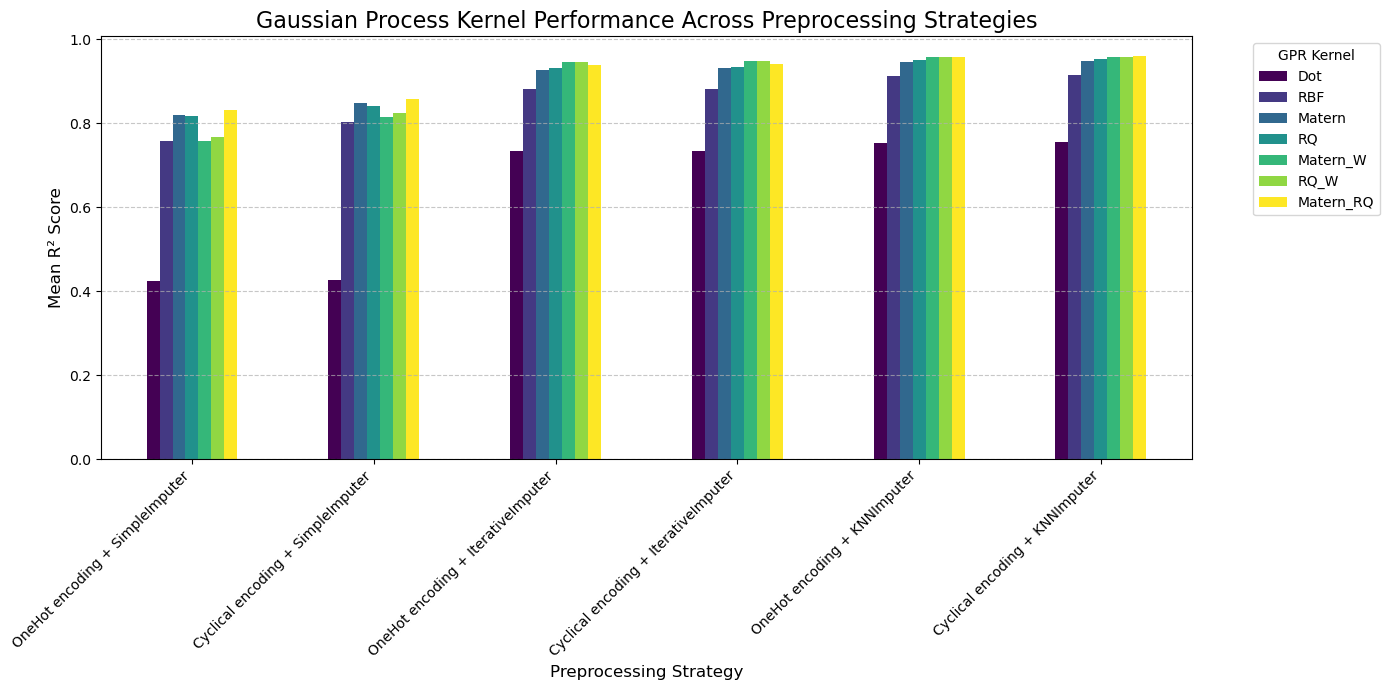

In [52]:
ax = master_R2.plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title('Gaussian Process Kernel Performance Across Preprocessing Strategies', fontsize=16)
plt.ylabel('Mean R² Score', fontsize=12)
plt.xlabel('Preprocessing Strategy', fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilts the text so it doesn't overlap
plt.legend(title='GPR Kernel', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds faint horizontal lines to make reading values easier
plt.tight_layout() # Ensures nothing gets cut off

plt.show()

In [53]:
print(master_R2)

                                           Dot       RBF    Matern        RQ  \
OneHot encoding + SimpleImputer       0.424965  0.756750  0.819994  0.817573   
Cyclical encoding + SimpleImputer     0.426133  0.803063  0.848191  0.841807   
OneHot encoding + IterativeImputer    0.733536  0.882235  0.925643  0.930603   
Cyclical encoding + IterativeImputer  0.734080  0.881080  0.930911  0.934740   
OneHot encoding + KNNImputer          0.753590  0.912412  0.946466  0.951192   
Cyclical encoding + KNNImputer        0.754474  0.913554  0.949221  0.953649   

                                      Matern_W      RQ_W  Matern_RQ  
OneHot encoding + SimpleImputer       0.757527  0.768141   0.831793  
Cyclical encoding + SimpleImputer     0.813739  0.825038   0.857287  
OneHot encoding + IterativeImputer    0.944777  0.944947   0.937911  
Cyclical encoding + IterativeImputer  0.948799  0.949050   0.941268  
OneHot encoding + KNNImputer          0.957226  0.956603   0.956818  
Cyclical encoding +

# Saving Results


In [43]:
gpr_Matern_RQ = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RationalQuadratic()+Matern(), alpha = 0.01))
# Use this function to fit the model
gpr_Matern_RQ.fit(X_train_cycKNN, y_train_base)
# Use this function for inference
y_pred = gpr_Matern_RQ.predict(X_test_cycKNN)

c:\Users\carlo\anaconda3\envs\IML\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [44]:
dt = pd.DataFrame(y_pred, columns = ['price_CHF']) 
dt.to_csv('results_cycKNN_Matern_RQ.csv', index=False)
print("\nResults file successfully generated!")


Results file successfully generated!


In [ ]:
gpr_Matern_W = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=Matern()+noise_k))
# Use this function to fit the model
gpr_Matern_W.fit(X_train_oneKNN, y_train_base)
# Use this function for inference
y_pred = gpr_Matern_W.predict(X_test_oneKNN)

dt = pd.DataFrame(y_pred, columns = ['price_CHF']) 
dt.to_csv('results_oneKNN_Matern_W.csv', index=False)
print("\nResults file successfully generated!")

In [49]:
gpr_RQ = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=RationalQuadratic()))
# Use this function to fit the model
gpr_RQ.fit(X_train_cycIte, y_train_base)
# Use this function for inference
y_pred = gpr_RQ.predict(X_test_cycIte)

dt = pd.DataFrame(y_pred, columns = ['price_CHF']) 
dt.to_csv('results_cycIte_RQ.csv', index=False)
print("\nResults file successfully generated!")


Results file successfully generated!


In [50]:
dt.head(10)

,price_CHF
0,4.400891
1,3.876701
2,4.902222
3,4.049386
4,3.298666
5,2.821745
6,2.031679
7,2.066021
8,1.886999
9,0.409455
